In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/ViT_Project/vision_transformer.py .

In [3]:
import torch
from torch import nn
from torch.utils.data import Subset
from torch.utils.data import default_collate
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cpu')

if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using CUDA")
else:
    device = torch.device('mps')
    print("Using MPS")


train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

cutmix = v2.CutMix(alpha=0.2, num_classes=10)
mixup = v2.MixUp(alpha=0.2, num_classes=10)
cutmix_or_mixup = transforms.v2.RandomChoice([cutmix, mixup])

# instantiating twice to get different transforms on train vs. val
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_transforms, download=True)
full_val_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=val_transforms, download=True)

train_size = int(len(full_train_dataset) * 0.9)

indices = torch.randperm(len(full_train_dataset))

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=val_transforms, download=True)

print(len(train_dataset), len(val_dataset), len(test_dataset))

# %load_ext autoreload
# %autoreload 2

Using CUDA


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


45000 5000 10000


In [4]:
batch_size = 512
num_workers = 4

def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, num_workers=num_workers, drop_last=True)

# for batch, labels in train_loader:
#     print(batch)
#     print(labels)
#     print(batch.shape)
#     print(labels.shape)
#     break

In [5]:
from vision_transformer import VisionTransformer

# training hyperparameters
train_iters = 325
checkpoint_interval = 10
lr = 4e-3
weight_decay = 0.05
label_smoothing = 0.0
eps = 1e-8

model = VisionTransformer().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, eps=eps)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=train_iters
)
scaler = torch.amp.GradScaler("cuda")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Trainable parameters: 9574922


In [6]:
# training helper functions
def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    num_correct = (preds == labels).sum().item()
    return num_correct

@torch.no_grad()
def evaluation(loader):

    model.eval()

    loss_sum = 0.0
    correct_preds = 0
    total = 0

    for batch, labels in loader:

        x = batch.to(device)
        targets = labels.to(device)

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out, targets)

        loss_sum += loss.item()

        correct_preds += compute_accuracy(out, targets)
        total += targets.size(0)


    model.train()

    avg_loss = loss_sum / len(loader)
    avg_acc = correct_preds / total

    return avg_loss, avg_acc

In [ ]:
train_losses = []
val_losses = []
val_accs = []
lrs = []

def plot_history(train_loss, val_loss, val_acc, lrs):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(18, 5)) # Made it wider to fit 3 plots

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_loss, 'r', label='Train Loss')
    plt.plot(epochs, val_loss, 'b', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot 2: Validation Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, val_acc, 'g', label='Val Acc')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    # Plot 3: Learning Rate (The new addition)
    plt.subplot(1, 3, 3)
    plt.plot(epochs, lrs, 'm', label='Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('LR')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0)) # Clean scientific notation
    plt.legend()

    plt.tight_layout()

    filename = "/content/drive/MyDrive/ViT_Project/graphs8.png"

    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

In [7]:
save_weights_path = "/content/drive/MyDrive/ViT_Project/vit_best_8.pth"

Epoch: 1 Train Loss: 2.1513 Val Loss: 1.9463 Validation Accuracy: 0.2654
Epoch: 2 Train Loss: 2.0526 Val Loss: 1.8024 Validation Accuracy: 0.3349
Epoch: 3 Train Loss: 1.8973 Val Loss: 1.6503 Validation Accuracy: 0.3924
Epoch: 4 Train Loss: 1.9053 Val Loss: 1.5274 Validation Accuracy: 0.4431
Epoch: 5 Train Loss: 1.8942 Val Loss: 1.4933 Validation Accuracy: 0.4659
Epoch: 6 Train Loss: 1.8009 Val Loss: 1.4468 Validation Accuracy: 0.4798
Epoch: 7 Train Loss: 1.7912 Val Loss: 1.3636 Validation Accuracy: 0.5054
Epoch: 8 Train Loss: 1.7580 Val Loss: 1.3537 Validation Accuracy: 0.5048
Epoch: 9 Train Loss: 1.7217 Val Loss: 1.2753 Validation Accuracy: 0.5267
Epoch: 10 Train Loss: 1.6898 Val Loss: 1.2437 Validation Accuracy: 0.5575
Best val acc: 0.5575
Epoch: 11 Train Loss: 1.7131 Val Loss: 1.2597 Validation Accuracy: 0.5508
Epoch: 12 Train Loss: 1.6639 Val Loss: 1.2360 Validation Accuracy: 0.5527
Epoch: 13 Train Loss: 1.6410 Val Loss: 1.1919 Validation Accuracy: 0.5720
Epoch: 14 Train Loss: 1.65

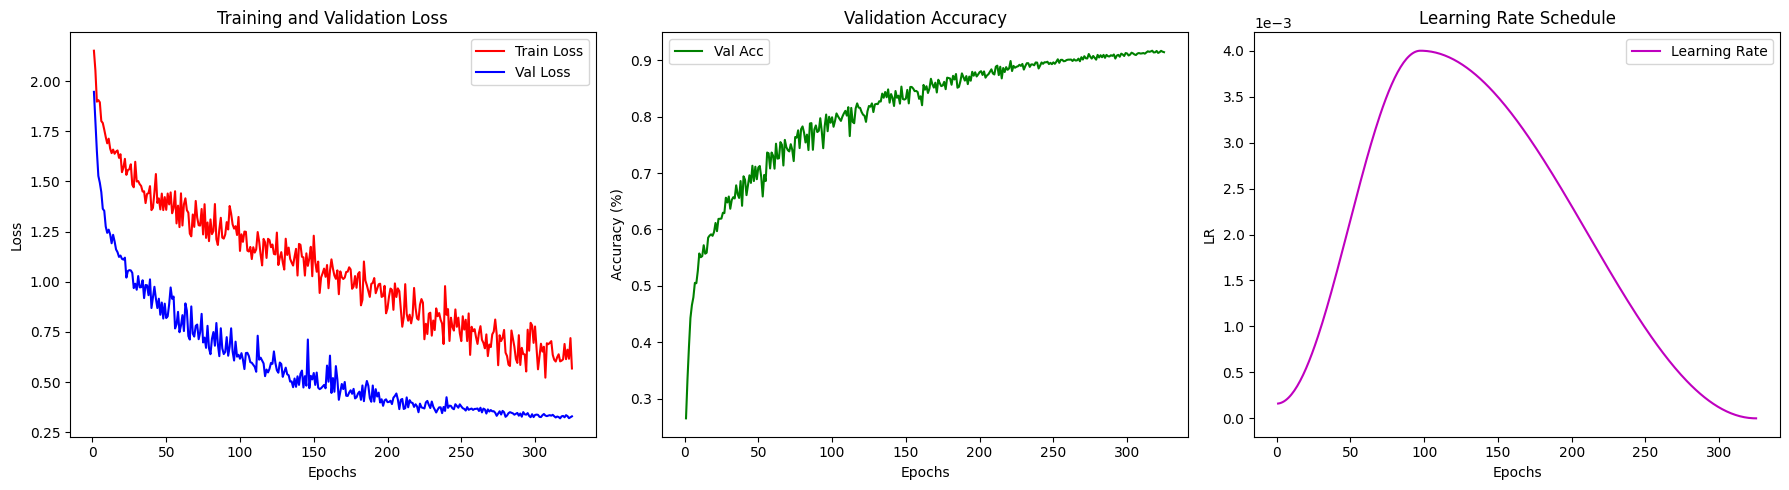

In [ ]:
best_val_acc = 0.0

for i in range(train_iters):

    train_losses_sum = 0.0

    model.train()

    for _, (batch, labels) in enumerate(train_loader):

        x = batch.to(device)
        targets = labels.to(device)

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out, targets)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_losses_sum += loss.item()

    avg_train_loss = train_losses_sum / len(train_loader)
    avg_val_loss, avg_val_acc = evaluation(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)
    lrs.append(optimizer.param_groups[0]['lr'])

    print(
        f"Epoch: {i + 1}"
        + f" Train Loss: {avg_train_loss:.4f}"
        + f" Val Loss: {avg_val_loss:.4f}"
        + f" Validation Accuracy: {avg_val_acc:.4f}"
    )

    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), save_weights_path)

    if (i + 1) % checkpoint_interval == 0 or i == train_iters - 1:
        print(f"Best val acc: {best_val_acc:.4f}")


plot_history(train_losses, val_losses, val_accs, lrs)

In [8]:
model.load_state_dict(torch.load(save_weights_path, map_location=device))
model.eval()
avg_test_loss, avg_test_acc = evaluation(test_loader)
print(f"Final Test Loss: {avg_test_loss:.4f}" + f" Final Test Accuracy: {avg_test_acc:.4f}")

Final Test Loss: 0.3177 Final Test Accuracy: 0.9152


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

# monkey patches forward pass to capture attention scores
def get_attention_maps(model, input_tensor):
    all_attentions = []

    # defines monkey patch for forward pass
    def patched_head_forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        d_k = q.shape[-1]

        # recomputes and stores attention
        weights = torch.softmax(q @ k.transpose(1, 2) / (d_k ** 0.5), dim=-1)
        self._captured_weights = weights.detach().cpu()

        return weights @ v

    # replaces forward pass of all heads in all blocks w/ monkey patch
    original_forwards = []
    for block in model.blocks:
        for head in block.MHA.heads:
            original_forwards.append((head, head.forward))
            head.forward = patched_head_forward.__get__(head, head.__class__)

    # runs forward pass
    model.eval()
    with torch.no_grad():
        _ = model(input_tensor.to(device))

    # averages attention across heads for each block
    for block in model.blocks:
        block_weights = [head._captured_weights for head in block.MHA.heads]
        avg_weights = torch.stack(block_weights).mean(dim=0)
        all_attentions.append(avg_weights)

    # restores original forward methods
    for head, orig_f in original_forwards:
        head.forward = orig_f

    return all_attentions # list of 12 65 x 65 matrices

# attention rollout: an attention interpretability method
def compute_rollout(all_attentions):
    # initialize to identity
    num_tokens = all_attentions[0].shape[-1]
    result = torch.eye(num_tokens)

    for attention in all_attentions:
        # add identity for residual connections
        I = torch.eye(num_tokens)
        a = (attention.squeeze(0) + I) / 2

        # normalize after adding identity
        a = a / a.sum(dim=-1, keepdim=True)

        # propagate attention through the 12 blocks
        result = torch.matmul(a, result)

    # get attention of just CLS token to all OTHER patches
    mask = result[0, 1:].reshape(8, 8).numpy()
    return mask

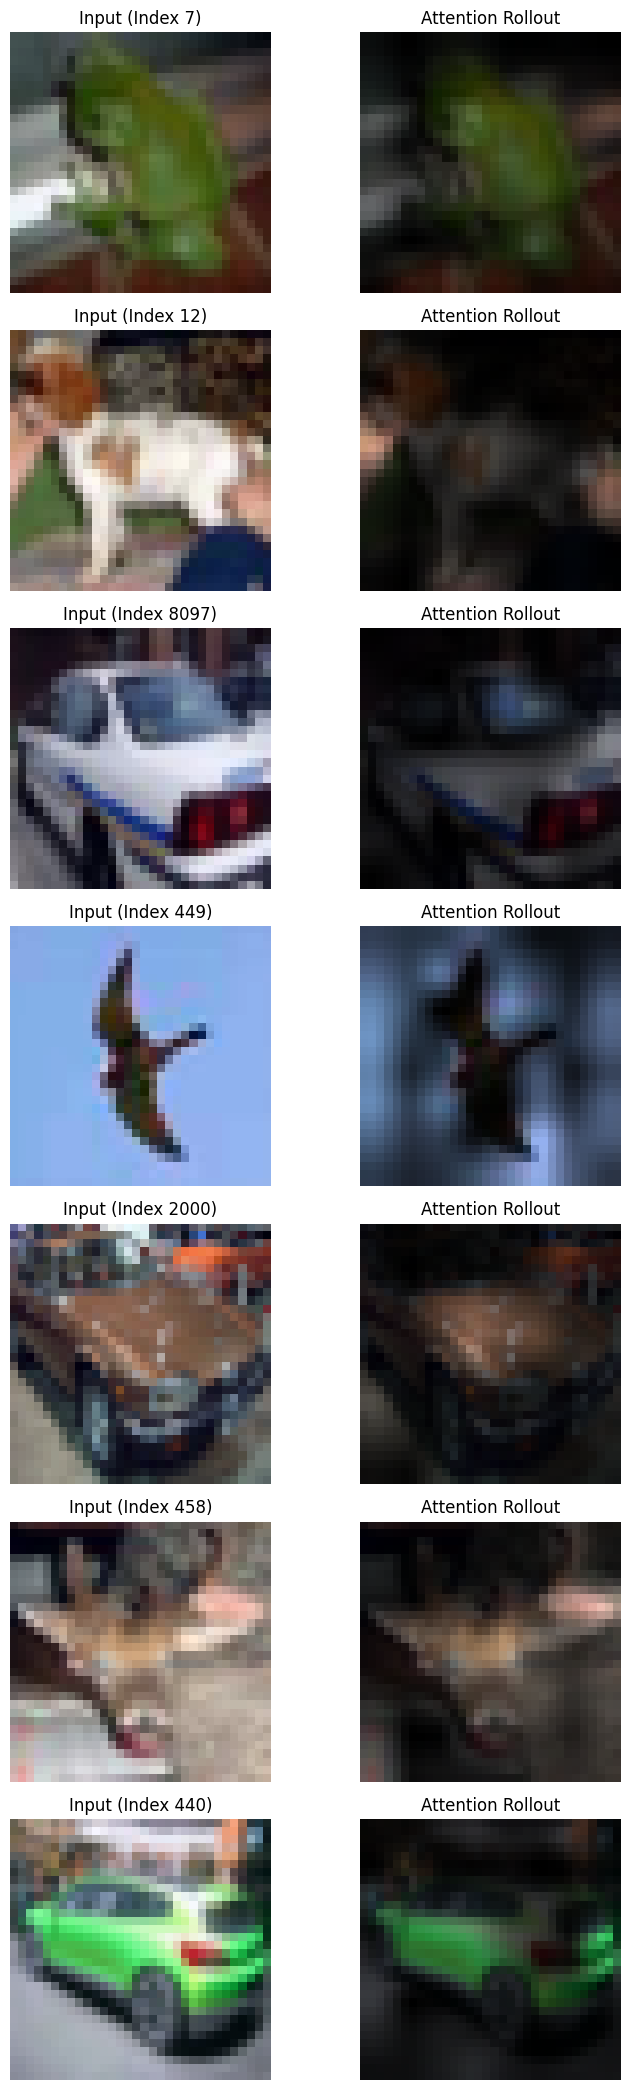

In [11]:
def plot_multiple_attentions(dataset, model, indices):
    num_imgs = len(indices)
    fig, axes = plt.subplots(num_imgs, 2, figsize=(8, 3 * num_imgs))

    for i, idx in enumerate(indices):
        image_tensor, _ = dataset[idx]

        # 1. Get attention rollout mask
        attentions = get_attention_maps(model, image_tensor.unsqueeze(0))
        mask = compute_rollout(attentions)

        # 2. Prepare original image for plotting
        img = image_tensor.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())

        # 3. Upscale mask to match image size
        mask_resized = cv2.resize(mask, (32, 32))
        mask_resized = (mask_resized - mask_resized.min()) / (mask_resized.max() - mask_resized.min())

        # 4. Plot Input
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Input (Index {idx})")
        axes[i, 0].axis('off')

        # 5. Plot Attention Overlay
        axes[i, 1].imshow(img * mask_resized[..., np.newaxis])
        axes[i, 1].set_title("Attention Rollout")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

sample_indices = [7, 12, 8097, 449, 2000, 458, 440]
plot_multiple_attentions(test_dataset, model, sample_indices)